In [1]:
# import libraries
import os
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from datasets import Dataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from transformers import Trainer, TrainingArguments
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# preprocessing - classical cleaning
# import re, nltk
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer

In [2]:
!pip install -q google-play-scraper


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.5 MB/s eta 0:00:00


In [3]:
# scrapper lib

from google_play_scraper import reviews
from google_play_scraper import Sort

## *Scrap playstore app review
https://www.kaggle.com/code/odins0n/play-store-app-reviews-scrapper-daily-update

In [4]:
# newest review for apps on google play store 

# top apps
apps={
    "Facebook": "com.facebook.katana",
    "WhatsApp": "com.whatsapp",
    "Spotify": "com.spotify.music",
}

SORT = Sort.NEWEST
N_REVIEWS = 10000
reviews_dict =  {k : {} for k in apps}


## Scraping reviews
for app in apps.keys():
    reviews_dict[app], _  = reviews(
         apps[app],
         lang='en',
         country='us',
         sort= SORT,
         count=N_REVIEWS, 
         filter_score_with=None
     )
    assert len(reviews_dict[app]) == N_REVIEWS
    
## saving reviews
df = pd.DataFrame()
for app in apps.keys():
    SAVE_DIR = app  + ".csv"
    temp_df = pd.DataFrame(
        reviews_dict[app],
        columns = ["reviewId", "content", "score"]
                          )
    temp_df.to_csv(SAVE_DIR, index = False)
    temp_df["app"] = app
    df = pd.concat((df ,temp_df))
df.to_csv("all_combined.csv", index = False)
print("DONE :) ")
df.head()


## references 
## https://github.com/facundoolano/google-play-scraper
## https://www.makeuseof.com/tag/most-popular-android-apps/

DONE :) 


,reviewId,content,score,app
0,df0a8da3-75b8-4468-9490-cf04189c9d4b,sorry,5,Facebook
1,aba98046-8f93-4c54-a61e-1f114a25c436,government FB shut down all accounts and took ...,1,Facebook
2,dc3089c9-d4a7-4285-a990-1411d4c1af26,"sele,k",5,Facebook
3,982eac2e-ec33-49cf-9fd9-727eaa599ff5,I’m really disappointed with the Facebook app ...,1,Facebook
4,9abbf939-1c88-4654-97dd-da6321a8c7ca,I used Facebook mainly for selling local produ...,1,Facebook


## 1. Load data & configuration

In [5]:
# load data
data = pd.read_csv('/kaggle/working/all_combined.csv')
data.head()

,reviewId,content,score,app
0,df0a8da3-75b8-4468-9490-cf04189c9d4b,sorry,5,Facebook
1,aba98046-8f93-4c54-a61e-1f114a25c436,government FB shut down all accounts and took ...,1,Facebook
2,dc3089c9-d4a7-4285-a990-1411d4c1af26,"sele,k",5,Facebook
3,982eac2e-ec33-49cf-9fd9-727eaa599ff5,I’m really disappointed with the Facebook app ...,1,Facebook
4,9abbf939-1c88-4654-97dd-da6321a8c7ca,I used Facebook mainly for selling local produ...,1,Facebook


In [6]:
dfs = pd.read_csv("/kaggle/working/Spotify.csv") #app = spotify
dfs.head()

,reviewId,content,score
0,29850eab-6058-4288-b8cd-0268996e10b6,Its the best,5
1,cd73ad8d-e049-45f8-a861-3be74670967b,Could you please fix the scrolling issue where...,3
2,b2e21ab2-abb6-4cdd-8b83-80b570263aed,it's nice to listen,5
3,5e920f8f-37fb-42e2-a24a-895a697c29a0,"Since the last update, I can no longer see the...",2
4,12e5eec3-965a-41da-ad1e-7d788e09e6f2,I had a very bad experience i have been using ...,1


## 2. EDA (Explanatory Data Analysis)

### Overall analysis

In [7]:
# dataset detail
print(data.shape)
print(data.dtypes)
print(data.describe())

(30000, 4)
reviewId    object
content     object
score        int64
app         object
dtype: object
              score
count  30000.000000
mean       3.719567
std        1.706250
min        1.000000
25%        2.000000
50%        5.000000
75%        5.000000
max        5.000000


In [8]:
# drop null
print(data.isnull().sum())

reviewId    0
content     1
score       0
app         0
dtype: int64


/tmp/ipykernel_57/1503099127.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='score', y='app', data=data, palette=custom_palette, inner='quartile', cut=0)


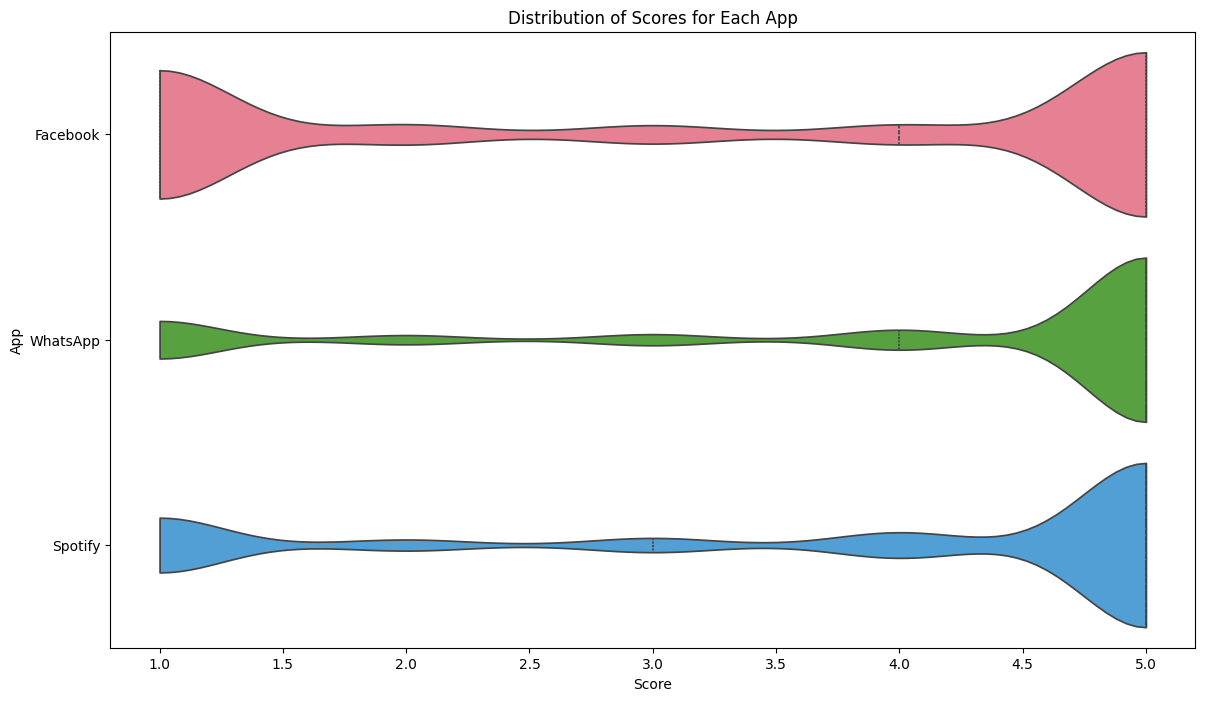

In [9]:
# Create a custom color palette with a distinct color for each app
custom_palette = sns.color_palette("husl", n_colors=len(data['app'].unique()))

# Distribution of Scores - Violin Plot
plt.figure(figsize=(14, 8))
sns.violinplot(x='score', y='app', data=data, palette=custom_palette, inner='quartile', cut=0)
plt.title('Distribution of Scores for Each App')
plt.xlabel('Score')
plt.ylabel('App')

# Show the plot
plt.show()

In [10]:
# Create a new column for review lengths, replacing NaN values with an empty string
data['review_length'] = data['content'].fillna('').apply(len)
data.columns
data['app'].unique()

array(['Facebook', 'WhatsApp', 'Spotify'], dtype=object)

/tmp/ipykernel_57/1645103373.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['review_length'], y=data['app'], palette=custom_palette, showfliers=False)


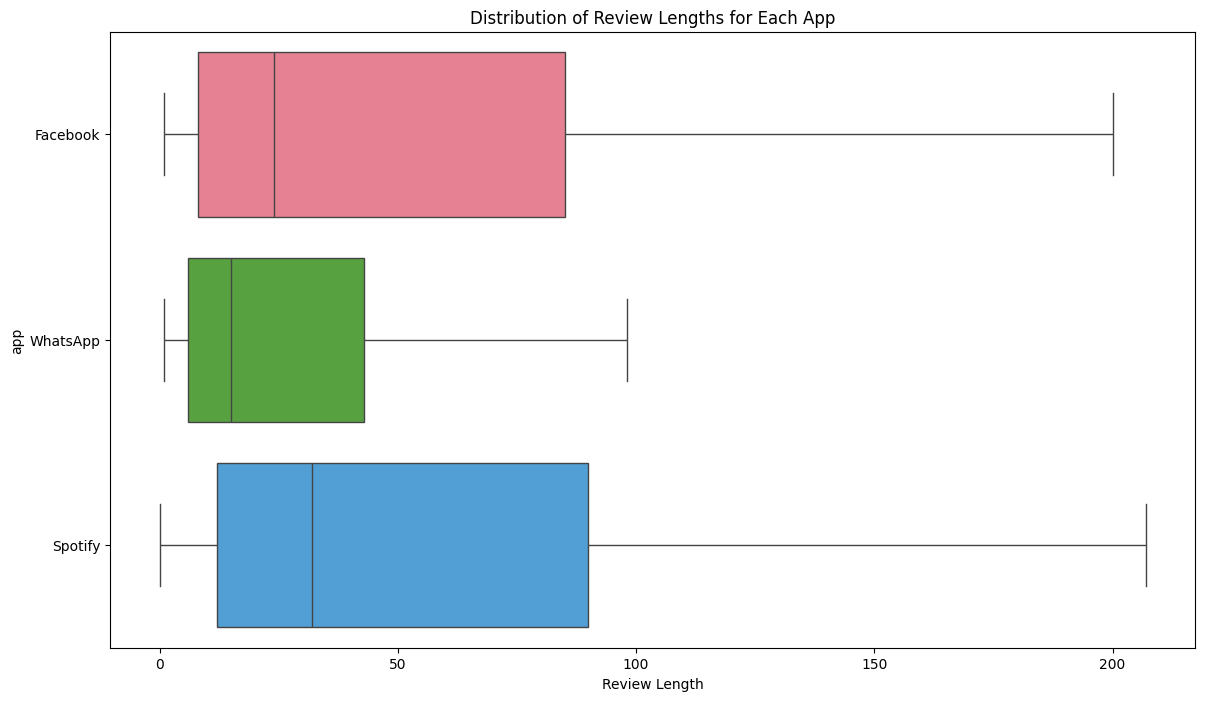

In [11]:
# Distribution review lengths
# Create a custom color palette with a distinct color for each app
custom_palette = sns.color_palette("husl", n_colors=len(data['app'].unique()))


# Distribution of Review Lengths 
plt.figure(figsize=(14, 8))
sns.boxplot(x=data['review_length'], y=data['app'], palette=custom_palette, showfliers=False)
plt.title('Distribution of Review Lengths for Each App')
plt.xlabel('Review Length')


# Show the plot
plt.show()

In [12]:
data.dropna(inplace = True)


counts = data["score"].value_counts().reset_index()
counts = counts.sort_values(by="score")

counts["label_star"] = counts["score"].astype("str") + str(" ⭐")
# CLASS_LABELS = counts["index"].to_list()

fig = px.bar(
    data_frame= counts,
    x = "label_star",
    y = "score" , 
    color = "count" ,
    color_continuous_scale="Emrld") 
fig.update_xaxes(title="Score")
fig.update_yaxes(title = "Number of Reviews")
fig.update_layout(showlegend = True,
    title = {
        'text': 'Data Distribution ',
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})

### spotify

In [13]:
# dataset detail - spotify
print(data.shape)
print(data.dtypes)
print(data.describe())

(29999, 5)
reviewId         object
content          object
score             int64
app              object
review_length     int64
dtype: object
              score  review_length
count  29999.000000   29999.000000
mean       3.719557      64.870796
std        1.706277     102.088012
min        1.000000       1.000000
25%        2.000000       8.000000
50%        5.000000      23.000000
75%        5.000000      70.000000
max        5.000000     512.000000


In [14]:
dfs.isnull().sum()

reviewId    0
content     1
score       0
dtype: int64

In [15]:
# clean nulls
dfs = dfs.dropna(subset=["content"])

In [16]:
print(dfs.isnull().sum())
print(dfs["content"].head())

reviewId    0
content     0
score       0
dtype: int64
0                                         Its the best
1    Could you please fix the scrolling issue where...
2                                  it's nice to listen
3    Since the last update, I can no longer see the...
4    I had a very bad experience i have been using ...
Name: content, dtype: object


In [17]:
# dfs.isnull().sum()
dfs.head()

,reviewId,content,score
0,29850eab-6058-4288-b8cd-0268996e10b6,Its the best,5
1,cd73ad8d-e049-45f8-a861-3be74670967b,Could you please fix the scrolling issue where...,3
2,b2e21ab2-abb6-4cdd-8b83-80b570263aed,it's nice to listen,5
3,5e920f8f-37fb-42e2-a24a-895a697c29a0,"Since the last update, I can no longer see the...",2
4,12e5eec3-965a-41da-ad1e-7d788e09e6f2,I had a very bad experience i have been using ...,1


In [18]:
dfs.head()

,reviewId,content,score
0,29850eab-6058-4288-b8cd-0268996e10b6,Its the best,5
1,cd73ad8d-e049-45f8-a861-3be74670967b,Could you please fix the scrolling issue where...,3
2,b2e21ab2-abb6-4cdd-8b83-80b570263aed,it's nice to listen,5
3,5e920f8f-37fb-42e2-a24a-895a697c29a0,"Since the last update, I can no longer see the...",2
4,12e5eec3-965a-41da-ad1e-7d788e09e6f2,I had a very bad experience i have been using ...,1


## 3. Preprocessing text (light)

In [19]:
def min_clean(text):
    return str(text).strip()

# example
text=" hello w              "
min_clean(text)
# transformer trained on natural raw text - don't need classical cleaning

'hello w'

## 4. Label Engineering/dataset setup

In [20]:
# convert rating -> sentiment
def label_sentiment(rating):
    if rating>=4:
        return 2 #positive
    elif rating==3:
        return 1 #neutral
    else:
        return 0 #negative

# apply on pandas
dfs["label"]=dfs["score"].apply(label_sentiment)

In [21]:
dfs.head() # labelled ver

,reviewId,content,score,label
0,29850eab-6058-4288-b8cd-0268996e10b6,Its the best,5,2
1,cd73ad8d-e049-45f8-a861-3be74670967b,Could you please fix the scrolling issue where...,3,1
2,b2e21ab2-abb6-4cdd-8b83-80b570263aed,it's nice to listen,5,2
3,5e920f8f-37fb-42e2-a24a-895a697c29a0,"Since the last update, I can no longer see the...",2,0
4,12e5eec3-965a-41da-ad1e-7d788e09e6f2,I had a very bad experience i have been using ...,1,0


In [22]:
# config
class config:
    MODEL_NAME = "distilbert-base-uncased"
    TOKENIZER_NAME = "distilbert-base-uncased"
    MAX_LEN = 64
    LOWER_CASE = True
    RANDOM_STATE = 12
    TEST_SIZE = 0.2
    NUM_LABELS = 3
    BATCH_SIZE = 128
    LEARNING_RATE = 2e-5
    EPOCHS = 10
    WEIGTH_DECAY = 0.01
    DEVICE = "cuda"

In [23]:
# drop unecessary col -conv hf ds - split
dfs=dfs.drop(columns=["reviewId", "score"])
dataset = Dataset.from_pandas(dfs)
dataset=dataset.train_test_split(test_size=config.TEST_SIZE,
                                seed=config.RANDOM_STATE)

## 5. Tokenization

In [24]:
# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()
# secret_value_0 = user_secrets.get_secret("HF_TOKEN")

# %pip install sentencepiece tiktoken
# %pip install transformers==4.45.2 accelerate==0.34.2 sentencepiece


In [25]:
!rm -rf distilbert-base-uncased

In [26]:
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME, 
                                          do_lower_case=config.LOWER_CASE)

def tokenize(batch):
    return tokenizer (batch["content"], 
                      max_length = config.MAX_LEN, 
                      padding="max_length", 
                      truncation=True)


dataset = dataset.map(tokenize, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/7999 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

## 6. Model setup & train

In [27]:
# build cuda 11.x (support sm_60)
# %pip install torch==2.0.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [28]:
model = AutoModelForSequenceClassification.from_pretrained(
    # "bert-base-uncased",
    # num_labels=3
    config.MODEL_NAME,num_labels=config.NUM_LABELS
)
model = model.to(config.DEVICE)

# load encoder weights, classification head random init


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [29]:
## metrics function
# raw model output(logits) -> predicted class

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"Accuracy": acc,
            "Precision": precision, 
            "Recall":recall, 
            "F1 Score": f1}

## trainning areguments
logging_steps = len(dataset["train"]) // config.BATCH_SIZE
training_args = TrainingArguments(
                                  num_train_epochs=config.EPOCHS,
                                  learning_rate=config.LEARNING_RATE,
                                  per_device_train_batch_size=config.BATCH_SIZE,
                                  per_device_eval_batch_size=config.BATCH_SIZE,
                                  weight_decay=config.WEIGTH_DECAY,
                                  eval_strategy="epoch",
                                  disable_tqdm=False,
                                  logging_steps=logging_steps,
                                 output_dir ="./results",
                                 report_to="none")


#### Train model

In [30]:
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"Arch List: {torch.cuda.get_arch_list()}")


GPU: Tesla T4
CUDA Version: 12.8
Arch List: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [31]:
print(torch.cuda.get_arch_list())


['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [32]:
# %pip install --upgrade torch torchvision torchaudio --index-url https://pytorch.org
# %pip install --upgrade transformers accelerate


In [33]:
# trainer
# define per epoch, per patch (forward, loss, backeward, optimizer)
trainer = Trainer(model=model,
                 args=training_args,
                 compute_metrics=compute_metrics,
                 train_dataset=dataset["train"],
                 eval_dataset=dataset["test"],
                 processing_class=tokenizer)
trainer.train();

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score
1,No log,0.984836,0.811500,0.765861,0.811500,0.787368
2,1.182854,0.740902,0.874000,0.843802,0.874000,0.855441
3,1.182854,0.689859,0.882000,0.843818,0.882000,0.861426
4,0.683446,0.683702,0.881000,0.862343,0.881000,0.863528
5,0.683446,0.684112,0.880500,0.858813,0.880500,0.865455
6,0.569797,0.706590,0.878500,0.859095,0.878500,0.865797
7,0.569797,0.722619,0.877000,0.853410,0.877000,0.861721
8,0.502761,0.719546,0.881500,0.868957,0.881500,0.871814
9,0.502761,0.731847,0.881000,0.863201,0.881000,0.867848
10,0.443205,0.737171,0.881000,0.864011,0.881000,0.869899


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetric

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



## 7. Evaluation

In [34]:
y_test = dataset["test"]["label"]
preds= trainer.predict(dataset["test"])
metrics = preds.metrics
preds= preds.predictions
y_preds = np.argmax(preds, axis=1)
print("Different Classification Metrics score on test data:")
metrics

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



Different Classification Metrics score on test data:


{'test_loss': 0.7371712923049927,
 'test_Accuracy': 0.881,
 'test_Precision': 0.8640113686650716,
 'test_Recall': 0.881,
 'test_F1 Score': 0.8698988739153557,
 'test_runtime': 2.233,
 'test_samples_per_second': 895.648,
 'test_steps_per_second': 3.583}

In [35]:
list(set(dfs["label"]))

[0, 1, 2]

#### Confusion Matrix

In [36]:
LABELS=list(set(dfs["label"]))
cm_data = confusion_matrix(y_test, y_preds)
cm = pd.DataFrame(cm_data, columns=LABELS, index=LABELS)

fig = px.imshow(img=cm_data,
               x=LABELS,
               y=LABELS,
               aspect="auto",
               color_continuous_scale="Blues",
               text_auto=True)
fig.update_xaxes(title="Predicted")
fig.update_yaxes(title="Actual")
fig.update_layout(title="Confusion Matrix",
                 template="plotly_white",
                 title_x = 0.5)
fig.show()

### Sentiment Dist

In [37]:
sent_counts=dfs["label"].value_counts().sort_index()


# percentages
tot=len(dfs)
percentages=(sent_counts / tot)*100
print(percentages)

label
0    24.402440
1     5.270527
2    70.327033
Name: count, dtype: float64


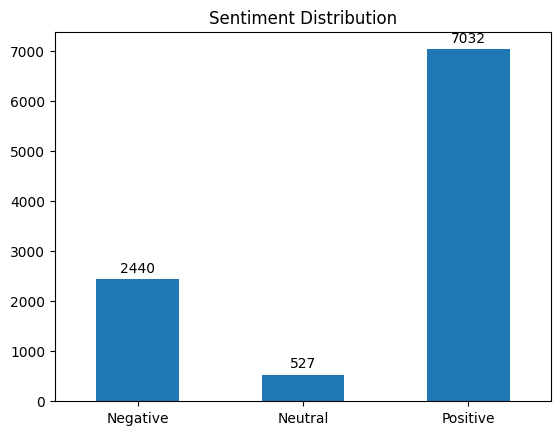

<Figure size 1500x1000 with 0 Axes>

In [38]:
sent_counts=dfs["label"].value_counts().sort_index()
sent_counts.index=["Negative", "Neutral", "Positive"]

# plot
# obj ax
ax=sent_counts.plot(kind="bar")
ax.bar_label(ax.containers[0], padding=3)

plt.title("Sentiment Distribution")
plt.xticks(rotation=0)
plt.figure(figsize=(15,10))
plt.show()

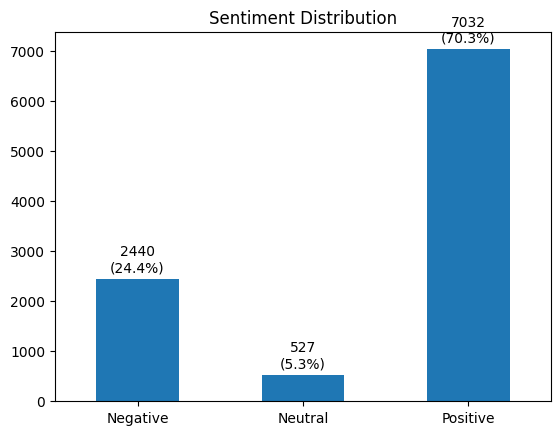

<Figure size 1500x1000 with 0 Axes>

In [39]:
sent_counts.index=["Negative", "Neutral", "Positive"]

# plot
# obj ax
ax=sent_counts.plot(kind="bar")

labels=[f'{count}\n({pct:.1f}%)' for count, pct in zip(sent_counts, percentages)]
ax.bar_label(ax.containers[0], labels=labels, padding=3)

plt.title("Sentiment Distribution")
plt.xticks(rotation=0)
plt.figure(figsize=(15,10))
plt.show()

**Sentiment Distribution Overview**

* Overall 71% user reviews on Spotify on play store shows strong positive distribution thate xpress users satisfaction of this music app. While still there are 23% negative sentiment represents critical segment of users experiencing friction more than neutral reviews.

* This Distribution shows that the apps already have stable brand reputation but attention should be given to resolving recurring issues in the negative feedback to prevent customer churn from the product

### Top Keywords

In [40]:
from collections import Counter

negative_text = " ".join(dfs[dfs["label"]==0]["content"])
Counter(negative_text.split()).most_common(20)

[('to', 2283),
 ('the', 1943),
 ('I', 1601),
 ('and', 1408),
 ('a', 1089),
 ('it', 1068),
 ('is', 1005),
 ('app', 861),
 ('for', 795),
 ('you', 731),
 ('of', 680),
 ('this', 609),
 ('my', 568),
 ('songs', 543),
 ('ads', 500),
 ('premium', 499),
 ('not', 498),
 ('have', 484),
 ('music', 482),
 ('but', 467)]

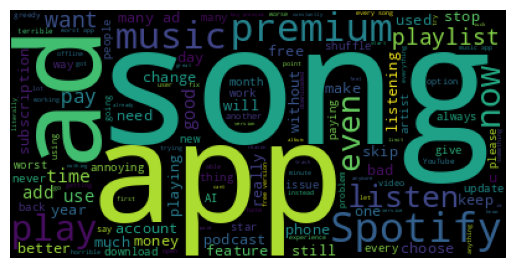

In [41]:
from wordcloud import WordCloud

text = " ".join(dfs[dfs["label"]==0]["content"])
wc = WordCloud().generate(text)

plt.axis("off")
plt.imshow(wc)

The most common word on negative reviews is with key word "song", "ad", "app", "Premium" and the others shown on the visualization chart.

* This result shows that most of the negative reviews triggered by frequent ad and premium subscription offering which limits the user experience continuously

### Classification Report

In [42]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.78      0.83      0.81       466
           1       0.32      0.12      0.18       100
           2       0.93      0.95      0.94      1434

    accuracy                           0.88      2000
   macro avg       0.68      0.63      0.64      2000
weighted avg       0.86      0.88      0.87      2000



### ROC AUC - multiclass

In [43]:
predictions = trainer.predict(dataset["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



In [44]:
from sklearn.preprocessing import label_binarize
from scipy.special import softmax
# 1. Get logits & labels
logits = predictions.predictions
labels = predictions.label_ids

# 2. Convert logits -> probabilities
probs = softmax(logits, axis=1)

# 3. Binarize labels
labels_bin = label_binarize(labels, classes=[0, 1, 2])

# 4. Compute ROC-AUC
roc_auc_weighted = roc_auc_score(
    labels_bin,
    probs,
    multi_class="ovr",
    average="weighted"
)

roc_auc_macro = roc_auc_score(
    labels_bin,
    probs,
    multi_class="ovr",
    average="macro"
)

print(f"ROC-AUC (weighted): {roc_auc_weighted:.4f}")
print(f"ROC-AUC (macro): {roc_auc_macro:.4f}")

ROC-AUC (weighted): 0.9522
ROC-AUC (macro): 0.9133


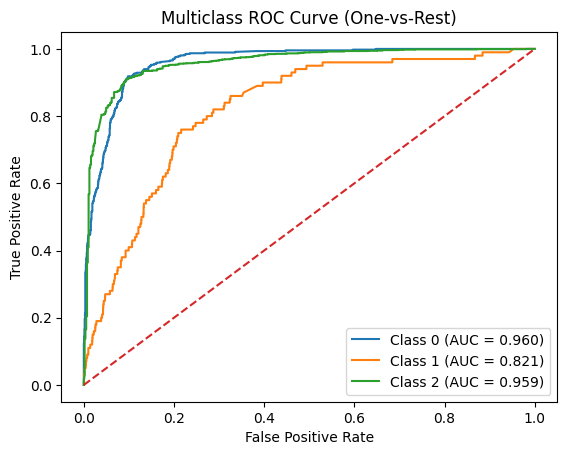

In [45]:
from sklearn.metrics import auc
# plot roc curve
plt.figure()

classes=[0,1,2]
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

# 5. Plot diagonal (random guess)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend()

plt.show()

## Class imbalance handling

In [46]:
# lib
from sklearn.utils.class_weight import compute_class_weight
import torch
from torch.nn import CrossEntropyLoss

In [47]:
dfs.head()

,content,label
0,Its the best,2
1,Could you please fix the scrolling issue where...,1
2,it's nice to listen,2
3,"Since the last update, I can no longer see the...",0
4,I had a very bad experience i have been using ...,0


In [48]:
# weighted cross entropy

# 1. compute class weight
class_weights=compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1,2]),
    y=dfs["label"]
)

class_weights=torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

# neutral punished much more

tensor([1.3660, 6.3245, 0.4740])


In [49]:
# 2. convert -> tensor
class_weights= torch.tensor(class_weights, dtype=torch.float)

print(class_weights)
print(type(class_weights))

tensor([1.3660, 6.3245, 0.4740])
<class 'torch.Tensor'>


/tmp/ipykernel_57/2426117806.py:2: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).



In [50]:
# 3. create custom trainer
model_weighted = AutoModelForSequenceClassification.from_pretrained(
    config.MODEL_NAME,
    num_labels=3
)
class WeightedTrainer(Trainer):

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels = inputs.get("labels")

        # forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # logits (batch size, num classes)
        

        # weighted loss
        loss_fct = CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )

        loss = loss_fct(
            logits.view(-1, logits.shape[-1]),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [51]:
# replace trainer
# trainer
# define per epoch, per patch (forward, loss, backeward, optimizer)
# trainer = Trainer(model=model,
#                  args=training_args,
#                  compute_metrics=compute_metrics,
#                  train_dataset=dataset["train"],
#                  eval_dataset=dataset["test"],
#                  processing_class=tokenizer)
# trainer.train();
trainer_modified = WeightedTrainer(
    model=model_weighted,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer
)

In [52]:
trainer_modified.train();

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score
1,No log,0.771206,0.819000,0.870657,0.819000,0.840598
2,0.849866,0.700564,0.796000,0.884137,0.796000,0.831958
3,0.849866,0.690916,0.799000,0.885762,0.799000,0.834684
4,0.620177,0.713972,0.811500,0.880348,0.811500,0.839473
5,0.620177,0.735807,0.801500,0.882026,0.801500,0.834848
6,0.498412,0.761122,0.801000,0.884222,0.801000,0.836038
7,0.498412,0.836632,0.823500,0.877249,0.823500,0.846545
8,0.427987,0.841830,0.817500,0.878749,0.817500,0.843650
9,0.427987,0.873053,0.823000,0.876854,0.823000,0.846239
10,0.364647,0.870999,0.825000,0.879683,0.825000,0.848658


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead un

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



#### Evaluation (weighted cross entropy)

In [53]:
# Eval
y_test = dataset["test"]["label"]
preds= trainer_modified.predict(dataset["test"])
metrics = preds.metrics
preds= preds.predictions
y_preds = np.argmax(preds, axis=1)
print("Different Classification Metrics score on test data:")
metrics

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



Different Classification Metrics score on test data:


{'test_loss': 0.8709993362426758,
 'test_Accuracy': 0.825,
 'test_Precision': 0.8796828368324174,
 'test_Recall': 0.825,
 'test_F1 Score': 0.8486580071973882,
 'test_runtime': 2.1891,
 'test_samples_per_second': 913.621,
 'test_steps_per_second': 3.654}

In [54]:
LABELS=list(set(dfs["label"]))
cm_data = confusion_matrix(y_test, y_preds)
cm = pd.DataFrame(cm_data, columns=LABELS, index=LABELS)

fig = px.imshow(img=cm_data,
               x=LABELS,
               y=LABELS,
               aspect="auto",
               color_continuous_scale="Blues",
               text_auto=True)
fig.update_xaxes(title="Predicted")
fig.update_yaxes(title="Actual")
fig.update_layout(title="Confusion Matrix",
                 template="plotly_white",
                 title_x = 0.5)
fig.show()

In [55]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.77      0.78      0.78       466
           1       0.15      0.35      0.21       100
           2       0.97      0.87      0.92      1434

    accuracy                           0.82      2000
   macro avg       0.63      0.67      0.63      2000
weighted avg       0.88      0.82      0.85      2000



In [56]:
# 1. Get logits & labels
logits = predictions.predictions
labels = predictions.label_ids

# 2. Convert logits -> probabilities
probs = softmax(logits, axis=1)

# 3. Binarize labels
labels_bin = label_binarize(labels, classes=[0, 1, 2])

# 4. Compute ROC-AUC
roc_auc_weighted = roc_auc_score(
    labels_bin,
    probs,
    multi_class="ovr",
    average="weighted"
)

roc_auc_macro = roc_auc_score(
    labels_bin,
    probs,
    multi_class="ovr",
    average="macro"
)

print(f"ROC-AUC (weighted): {roc_auc_weighted:.4f}")
print(f"ROC-AUC (macro): {roc_auc_macro:.4f}")

ROC-AUC (weighted): 0.9522
ROC-AUC (macro): 0.9133


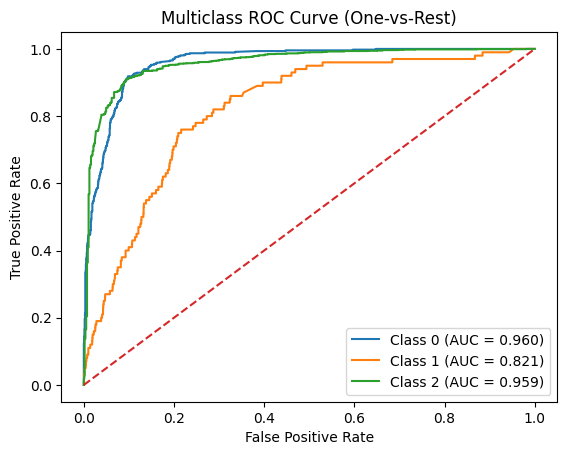

In [61]:
# plot roc curve
plt.figure()

classes=[0,1,2]
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

# 5. Plot diagonal (random guess)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend()

plt.show()

## Comparison

In [57]:
baseline_results = trainer.evaluate()
print(baseline_results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



{'eval_loss': 0.7371712923049927, 'eval_Accuracy': 0.881, 'eval_Precision': 0.8640113686650716, 'eval_Recall': 0.881, 'eval_F1 Score': 0.8698988739153557, 'eval_runtime': 2.2255, 'eval_samples_per_second': 898.654, 'eval_steps_per_second': 3.595, 'epoch': 10.0}


In [58]:
weighted_results = trainer_modified.evaluate()
print(weighted_results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning:

Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.



{'eval_loss': 0.8709993362426758, 'eval_Accuracy': 0.825, 'eval_Precision': 0.8796828368324174, 'eval_Recall': 0.825, 'eval_F1 Score': 0.8486580071973882, 'eval_runtime': 2.1907, 'eval_samples_per_second': 912.964, 'eval_steps_per_second': 3.652, 'epoch': 10.0}


In [59]:
# comparison

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "F1 Weighted",
        "Precision",
    ],

    "Baseline": [
        baseline_results["eval_Accuracy"],
        baseline_results["eval_F1 Score"],
        baseline_results["eval_Precision"],
    ],

    "Weighted": [
        weighted_results["eval_Accuracy"],
        weighted_results["eval_F1 Score"],
        weighted_results["eval_Precision"],
    ]
})


comparison

,Metric,Baseline,Weighted
0,Accuracy,0.881000,0.825000
1,F1 Weighted,0.869899,0.848658
2,Precision,0.864011,0.879683


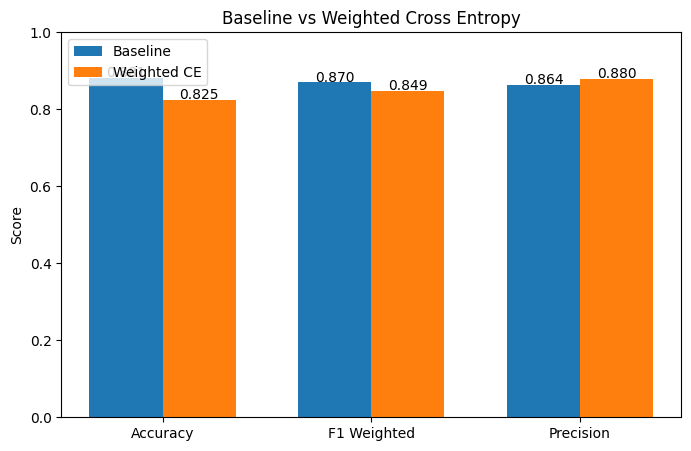

In [60]:
metrics = comparison["Metric"]

baseline=comparison["Baseline"]
weighted=comparison["Weighted"]

x=np.arange(len(metrics))
width=0.35

# create figure
plt.figure(figsize=(8,5))

# baseline
plt.bar(
    x - width/2,
    baseline,
    width,
    label="Baseline"
)

# weighted
plt.bar(
    x + width/2,
    weighted,
    width,
    label="Weighted CE"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Baseline vs Weighted Cross Entropy")
plt.legend()


for i, v in enumerate(baseline):
    plt.text(
        x[i] - width/2,
        v + 0.002,
        f"{v:.3f}",
        ha='center'
    )

for i, v in enumerate(weighted):
    plt.text(
        x[i] + width/2,
        v + 0.002,
        f"{v:.3f}",
        ha='center'
    )

plt.ylim(0,1)
plt.show()

Applying Weighted Cross Entropy increased model precision from 0.864 to 0.880, indicating that the model became more selective and produced fewer incorrect positive predictions. Overall Accuracy and Weighted F1 decreased, suggesting that the stronger minority-class penalization introduced a tradeoff between precision and overall classification balance.

This indicates that while class weighting improved prediction confidence, it may have caused the model to overcompensate for class imbalance, reducing generalization performance on the dominant classes.

* Weighted Cross Entropy : reduce majority class bias & improve minority class learning (punishment weight larger on majority class)
* F1 score (neutral class) still worked to improved from 0.18 to 0.21